In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("malnutrition_data.csv")

df.head()

,age_months,weight_kg,height_cm,muac_cm,bmi,nutrition_status
0,12.345052,3.000000,54.134002,13.160919,10.0,normal
1,30.807200,5.459076,76.199180,13.944380,10.0,normal
2,15.723226,3.000000,60.280820,13.243565,10.0,normal
3,57.796256,10.103074,104.990471,14.105683,10.0,normal
4,40.321320,7.110583,85.277902,14.641630,10.0,normal


In [2]:
df.shape

(5000, 6)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age_months        5000 non-null   float64
 1   weight_kg         5000 non-null   float64
 2   height_cm         5000 non-null   float64
 3   muac_cm           5000 non-null   float64
 4   bmi               5000 non-null   float64
 5   nutrition_status  5000 non-null   object 
dtypes: float64(5), object(1)
memory usage: 234.5+ KB


In [4]:
df.describe()

,age_months,weight_kg,height_cm,muac_cm,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.329540,5.285254,75.150343,13.441465,10.004274
std,17.152432,2.340930,17.332621,0.885567,0.047272
min,1.000686,3.000000,45.000000,10.261992,10.000000
25%,15.296946,3.000000,60.180769,12.849444,10.000000
50%,30.607902,4.648996,75.010021,13.635633,10.000000
75%,45.143969,7.043410,89.366628,14.082577,10.000000
max,59.989601,10.726919,105.000000,15.715103,11.285436


In [5]:
df["nutrition_status"].value_counts()

nutrition_status
normal      3550
moderate    1100
severe       350
Name: count, dtype: int64

In [6]:
df["nutrition_status"].value_counts(normalize=True) * 100

nutrition_status
normal      71.0
moderate    22.0
severe       7.0
Name: proportion, dtype: float64

In [7]:
df.isnull().sum()

age_months          0
weight_kg           0
height_cm           0
muac_cm             0
bmi                 0
nutrition_status    0
dtype: int64

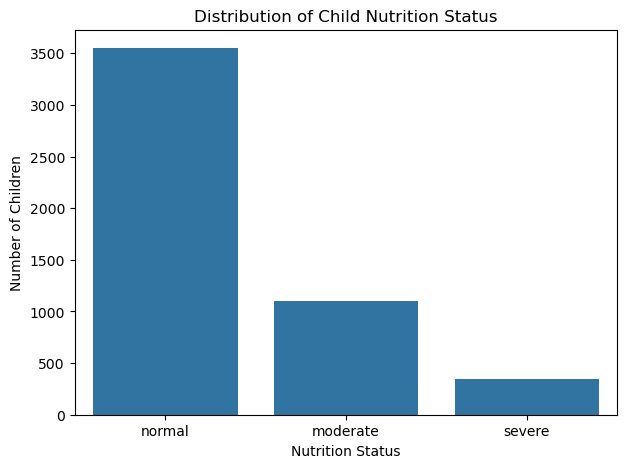

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="nutrition_status")

plt.title("Distribution of Child Nutrition Status")
plt.xlabel("Nutrition Status")
plt.ylabel("Number of Children")
plt.show()

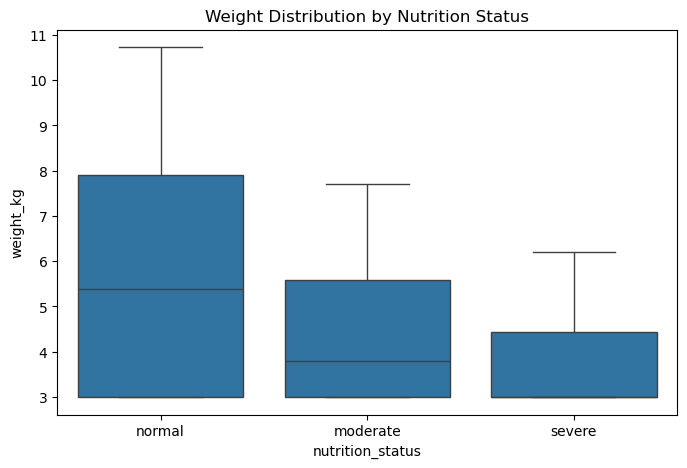

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="nutrition_status", y="weight_kg")

plt.title("Weight Distribution by Nutrition Status")
plt.show()

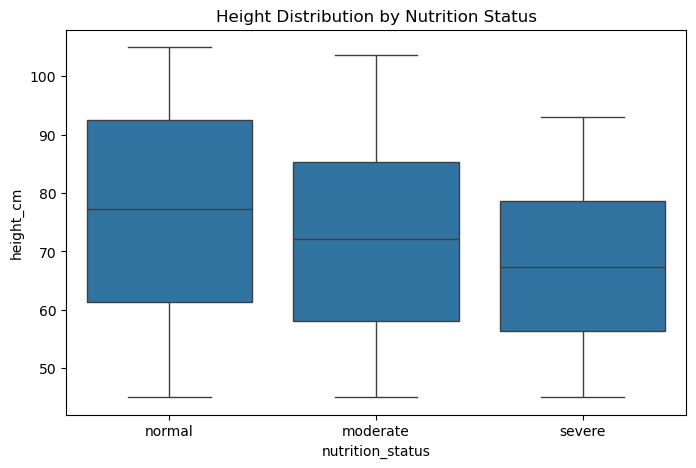

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="nutrition_status", y="height_cm")

plt.title("Height Distribution by Nutrition Status")
plt.show()

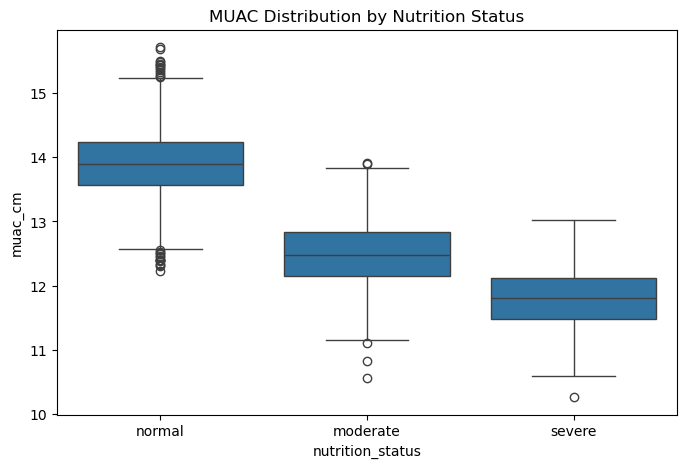

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="nutrition_status", y="muac_cm")

plt.title("MUAC Distribution by Nutrition Status")
plt.show()

In [12]:
X = df[["age_months", "weight_kg", "height_cm", "muac_cm"]]

y = df["nutrition_status"]

In [13]:
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age_months  weight_kg   height_cm    muac_cm
0   12.345052   3.000000   54.134002  13.160919
1   30.807200   5.459076   76.199180  13.944380
2   15.723226   3.000000   60.280820  13.243565
3   57.796256  10.103074  104.990471  14.105683
4   40.321320   7.110583   85.277902  14.641630

Target:
0    normal
1    normal
2    normal
3    normal
4    normal
Name: nutrition_status, dtype: object


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4000, 4)
Testing data: (1000, 4)


In [15]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['normal' 'moderate' 'normal' 'moderate' 'normal' 'normal' 'moderate'
 'normal' 'normal' 'normal']


In [17]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.909


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    moderate       0.77      0.83      0.80       220
      normal       0.97      0.97      0.97       710
      severe       0.73      0.50      0.59        70

    accuracy                           0.91      1000
   macro avg       0.82      0.77      0.79      1000
weighted avg       0.91      0.91      0.91      1000



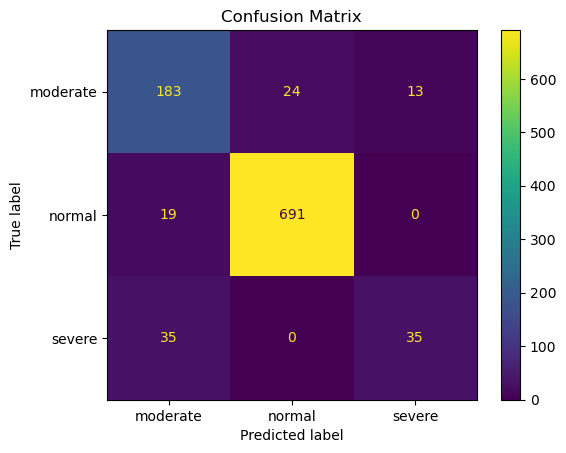

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [20]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

      Feature  Importance
3     muac_cm    0.890510
1   weight_kg    0.060465
0  age_months    0.043016
2   height_cm    0.006009


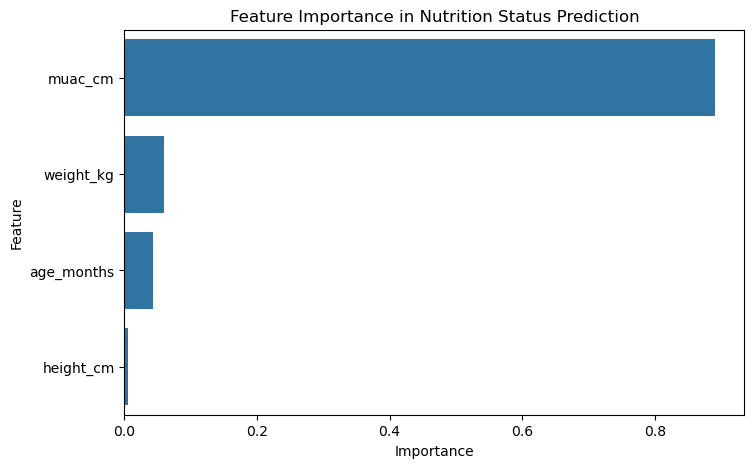

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Nutrition Status Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

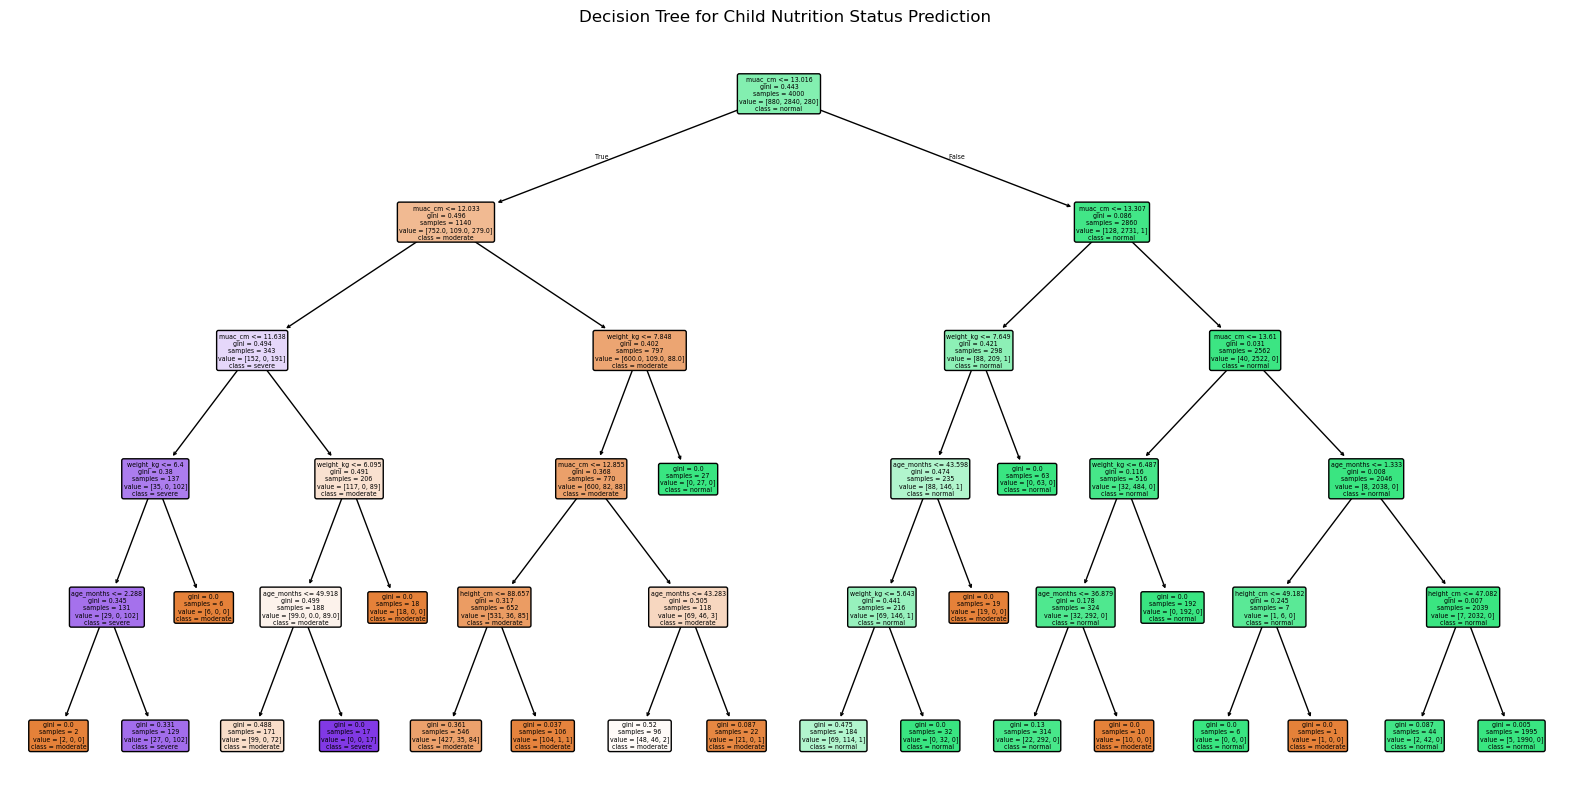

In [22]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Child Nutrition Status Prediction")

plt.show()

In [23]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.909

Classification Report:
              precision    recall  f1-score   support

    moderate       0.77      0.83      0.80       220
      normal       0.97      0.97      0.97       710
      severe       0.73      0.50      0.59        70

    accuracy                           0.91      1000
   macro avg       0.82      0.77      0.79      1000
weighted avg       0.91      0.91      0.91      1000



In [24]:
print(importance)

      Feature  Importance
3     muac_cm    0.890510
1   weight_kg    0.060465
0  age_months    0.043016
2   height_cm    0.006009


In [25]:
from sklearn.metrics import balanced_accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

Accuracy: 0.909
Balanced Accuracy: 0.7683525394793


In [26]:
balanced_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

    moderate       0.66      0.69      0.68       220
      normal       0.99      0.90      0.94       710
      severe       0.50      0.86      0.63        70

    accuracy                           0.85      1000
   macro avg       0.72      0.82      0.75      1000
weighted avg       0.88      0.85      0.86      1000



In [27]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score
)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Severe Recall"
    ],
    "Original Decision Tree": [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred, average="macro"),
        recall_score(y_test, y_pred, labels=["severe"], average=None)[0]
    ],
    "Balanced Decision Tree": [
        accuracy_score(y_test, y_pred_balanced),
        balanced_accuracy_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_balanced, average="macro"),
        recall_score(y_test, y_pred_balanced, labels=["severe"], average=None)[0]
    ]
})

print(comparison)

              Metric  Original Decision Tree  Balanced Decision Tree
0           Accuracy                0.909000                0.854000
1  Balanced Accuracy                0.768353                0.817426
2           Macro F1                0.787973                0.751300
3      Severe Recall                0.500000                0.857143


In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, recall_score

results = []

for depth in [3, 4, 5, 6, 7, 8, 10]:

    model_temp = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    model_temp.fit(X_train, y_train)

    pred_temp = model_temp.predict(X_test)

    results.append({
        "Max Depth": depth,
        "Accuracy": accuracy_score(y_test, pred_temp),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred_temp),
        "Macro F1": f1_score(y_test, pred_temp, average="macro"),
        "Severe Recall": recall_score(
            y_test,
            pred_temp,
            labels=["severe"],
            average=None
        )[0]
    })

results_df = pd.DataFrame(results)

print(results_df.round(3))

   Max Depth  Accuracy  Balanced Accuracy  Macro F1  Severe Recall
0          3     0.839              0.810     0.740          0.857
1          4     0.882              0.825     0.771          0.857
2          5     0.854              0.817     0.751          0.857
3          6     0.889              0.839     0.790          0.857
4          7     0.893              0.848     0.796          0.871
5          8     0.908              0.864     0.823          0.857
6         10     0.916              0.861     0.830          0.829


In [29]:
for depth in [8, 10]:

    final_temp = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    final_temp.fit(X_train, y_train)

    pred = final_temp.predict(X_test)

    print("=" * 50)
    print(f"DECISION TREE - MAX DEPTH {depth}")
    print("=" * 50)

    print("Accuracy:", accuracy_score(y_test, pred))
    print("\nClassification Report:")
    print(classification_report(y_test, pred))

DECISION TREE - MAX DEPTH 8
Accuracy: 0.908

Classification Report:
              precision    recall  f1-score   support

    moderate       0.80      0.78      0.79       220
      normal       0.99      0.95      0.97       710
      severe       0.61      0.86      0.71        70

    accuracy                           0.91      1000
   macro avg       0.80      0.86      0.82      1000
weighted avg       0.92      0.91      0.91      1000

DECISION TREE - MAX DEPTH 10
Accuracy: 0.916

Classification Report:
              precision    recall  f1-score   support

    moderate       0.82      0.79      0.81       220
      normal       0.98      0.96      0.97       710
      severe       0.62      0.83      0.71        70

    accuracy                           0.92      1000
   macro avg       0.81      0.86      0.83      1000
weighted avg       0.92      0.92      0.92      1000



In [30]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for depth in [8, 10]:

    cv_model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    scores = cross_validate(
        cv_model,
        X,
        y,
        cv=cv,
        scoring=[
            "accuracy",
            "balanced_accuracy",
            "f1_macro"
        ]
    )

    print("=" * 50)
    print(f"MAX DEPTH: {depth}")
    print("=" * 50)

    print("Mean Accuracy:",
          scores["test_accuracy"].mean())

    print("Mean Balanced Accuracy:",
          scores["test_balanced_accuracy"].mean())

    print("Mean Macro F1:",
          scores["test_f1_macro"].mean())

MAX DEPTH: 8
Mean Accuracy: 0.9054
Mean Balanced Accuracy: 0.8541168221449912
Mean Macro F1: 0.8187344167108359
MAX DEPTH: 10
Mean Accuracy: 0.9102
Mean Balanced Accuracy: 0.8567666605694775
Mean Macro F1: 0.825285362297211


In [31]:
DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [32]:
# Final Decision Tree Model

final_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    class_weight="balanced",
    random_state=42
)

final_model.fit(X_train, y_train)

# Predictions
y_pred_final = final_model.predict(X_test)

print("Final Model Accuracy:",
      accuracy_score(y_test, y_pred_final))

print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final))

Final Model Accuracy: 0.916

Final Classification Report:
              precision    recall  f1-score   support

    moderate       0.82      0.79      0.81       220
      normal       0.98      0.96      0.97       710
      severe       0.62      0.83      0.71        70

    accuracy                           0.92      1000
   macro avg       0.81      0.86      0.83      1000
weighted avg       0.92      0.92      0.92      1000



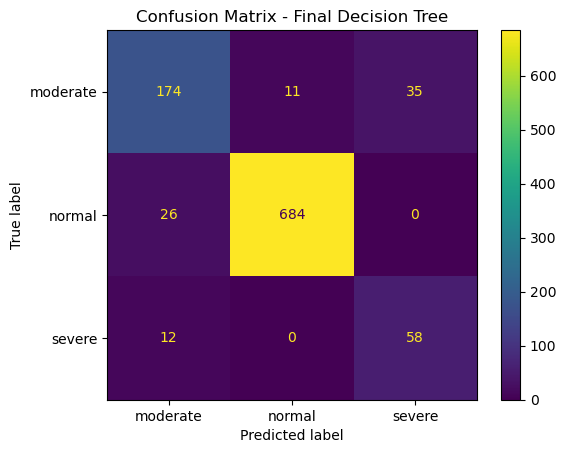

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=final_model.classes_
)

plt.title("Confusion Matrix - Final Decision Tree")
plt.show()

In [34]:
final_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print(final_importance)

      Feature  Importance
3     muac_cm    0.672982
0  age_months    0.149027
1   weight_kg    0.126864
2   height_cm    0.051127


In [35]:
import joblib

joblib.dump(final_model, "child_nutrition_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [36]:
import os

print(os.path.getsize("child_nutrition_model.pkl"), "bytes")

22593 bytes


In [37]:
import os

print(os.path.exists("child_nutrition_model.pkl"))

True


In [38]:
import joblib

loaded_model = joblib.load("child_nutrition_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [39]:
import pandas as pd

In [40]:
new_child = pd.DataFrame({
    "age_months": [24],
    "weight_kg": [8],
    "height_cm": [75],
    "muac_cm": [11]
})

prediction = loaded_model.predict(new_child)

print("Predicted Nutrition Status:", prediction[0])

Predicted Nutrition Status: moderate


In [41]:
probabilities = loaded_model.predict_proba(new_child)

for class_name, probability in zip(
    loaded_model.classes_,
    probabilities[0]
):
    print(f"{class_name}: {probability:.2%}")

moderate: 100.00%
normal: 0.00%
severe: 0.00%


In [42]:
import sklearn
import pandas
import joblib
import streamlit

print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)
print("streamlit:", streamlit.__version__)

scikit-learn: 1.7.2
pandas: 2.3.3
joblib: 1.5.2
streamlit: 1.51.0


In [43]:
app_code = '''
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("child_nutrition_model.pkl")

st.set_page_config(
    page_title="Child Nutrition Predictor",
    page_icon="🧒",
    layout="centered"
)

st.title("🧒 Child Nutrition Status Predictor")

st.write(
    "Enter the child's basic anthropometric measurements "
    "to predict the nutrition status using a Machine Learning model."
)

st.divider()

age = st.number_input(
    "Age (months)",
    min_value=0.0,
    max_value=60.0,
    value=24.0,
    step=1.0
)

weight = st.number_input(
    "Weight (kg)",
    min_value=0.1,
    max_value=30.0,
    value=8.0,
    step=0.1
)

height = st.number_input(
    "Height (cm)",
    min_value=30.0,
    max_value=150.0,
    value=75.0,
    step=0.1
)

muac = st.number_input(
    "MUAC (cm)",
    min_value=5.0,
    max_value=25.0,
    value=11.0,
    step=0.1
)

st.divider()

if st.button("🔍 Predict Nutrition Status", use_container_width=True):

    input_data = pd.DataFrame({
        "age_months": [age],
        "weight_kg": [weight],
        "height_cm": [height],
        "muac_cm": [muac]
    })

    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]

    st.subheader("Prediction Result")

    st.success(
        f"Predicted Nutrition Status: **{prediction.title()}**"
    )

    st.subheader("Prediction Probabilities")

    probability_df = pd.DataFrame({
        "Nutrition Status": model.classes_,
        "Probability": probabilities
    })

    probability_df["Probability"] = (
        probability_df["Probability"] * 100
    ).round(2)

    st.dataframe(
        probability_df,
        hide_index=True,
        use_container_width=True
    )

st.divider()

st.caption(
    "This application is an educational machine learning project "
    "and should not be used as a medical diagnosis."
)
'''

with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("app.py created successfully!")

app.py created successfully!
